# Evaluation

In [12]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = '1'
from pathlib import Path
from skimage import io as skio, morphology, measure
import numpy as np
import random
from matplotlib import pyplot as plt

import torch.nn.functional as F
from torchvision.transforms import v2 as transforms

from segment_anything import sam_model_registry
from torchvision.ops import sigmoid_focal_loss
from scipy.optimize import linear_sum_assignment
import torch
from matplotlib.patches import Circle

from tqdm.auto import tqdm
import shutil
import torch_fidelity
from PIL import Image

import json

In [13]:
results_path = Path("/mnt/experiments/robertob98/CUT_evaluation/evaluation_results.json")

with open(results_path, "r") as f:
    results_file = json.load(f) 

sam_loss_history = results_file["sam_loss_history"]
sam_tp_loss_history = results_file["sam_tp_loss_history"]
sam_fp_loss_history = results_file["sam_fp_loss_history"]
n_false_positives_history = results_file["n_false_positives_history"]
fid_history = results_file["fid_history"]

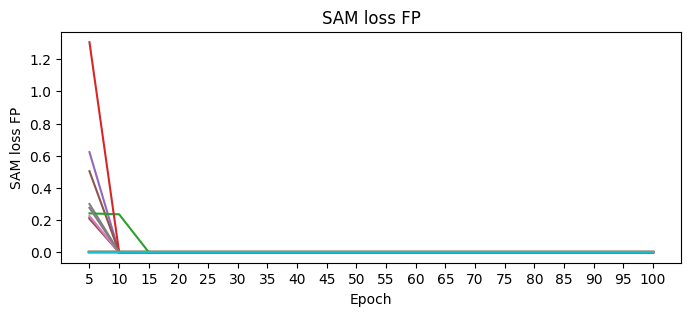

In [14]:
def plot_loss(loss_dict, loss_name, norm=False):
    plt.figure(figsize=(8, 3))
    for ld in loss_dict:
        if norm:
            min_ld = np.min(list(ld.values()))
            max_ld = np.max(list(ld.values()))
        xs = list(ld.keys())
        ys = []
        for epoch in xs:
            ys.append(ld[epoch] if not norm else (ld[epoch] - min_ld) / (max_ld - min_ld))
        plt.plot(xs, ys)
    plt.xlabel("Epoch")
    plt.ylabel(loss_name)
    plt.title(loss_name)
    plt.show()
plot_loss([sam_fp_loss_history], "SAM loss FP")

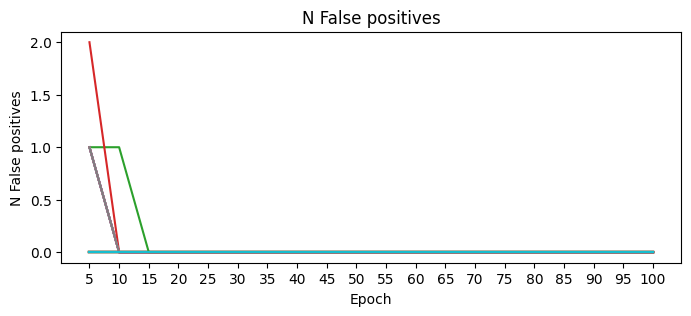

In [15]:
def plot_loss(loss_dict, loss_name, norm=False):
    plt.figure(figsize=(8, 3))
    for ld in loss_dict:
        if norm:
            min_ld = np.min(list(ld.values()))
            max_ld = np.max(list(ld.values()))
        xs = list(ld.keys())
        ys = []
        for epoch in xs:
            ys.append(ld[epoch] if not norm else (ld[epoch] - min_ld) / (max_ld - min_ld))
        plt.plot(xs, ys)
    plt.xlabel("Epoch")
    plt.ylabel(loss_name)
    plt.title(loss_name)
    plt.show()
plot_loss([n_false_positives_history], "N False positives")

In [16]:
np.min(list(fid_history.values()))

np.float64(114.6053085306114)

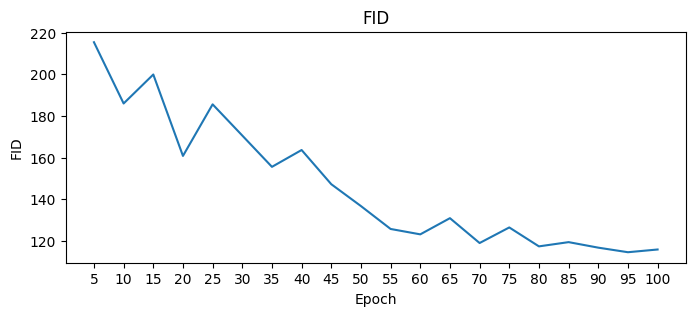

Lowest FID: 114.605 at epoch 95


In [17]:
plot_loss([fid_history], "FID")
fids = np.array(list(fid_history.values()))
print(f"Lowest FID: {np.min(fids):.3f} at epoch {list(fid_history.keys())[np.argmin(fids)]}")

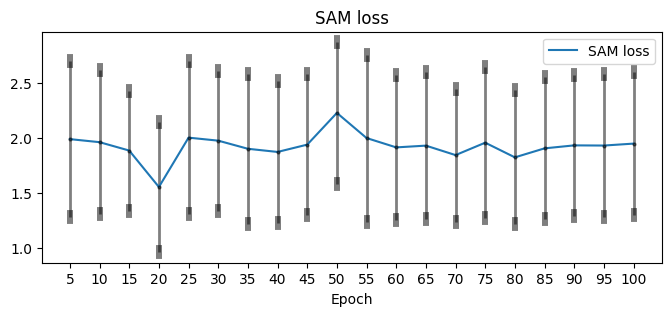

In [18]:
def plot_loss_gen(loss_dicts, loss_names):
    plt.figure(figsize=(8, 3))
    for ld in loss_dicts:
        xs = []
        ys = []
        error_bars = []
        for epoch, samples in ld.items():
            epoch_mean = np.mean(samples)
            epoch_std = np.std(samples)
            xs.append(epoch)
            ys.append(epoch_mean)
            error_bars.append(epoch_std)
            
        plt.errorbar(xs, ys, error_bars, fmt='.', color='Black', elinewidth=2,capthick=10,errorevery=1, alpha=0.5, ms=4, capsize = 2)
        plt.plot(xs, ys)
    plt.legend(loss_names)
    plt.ylim(bottom=max(0, plt.ylim()[0]))

    plt.xlabel("Epoch")
    plt.title(" vs. ".join(loss_names))
    plt.show()
plot_loss_gen([sam_loss_history], ["SAM loss"])

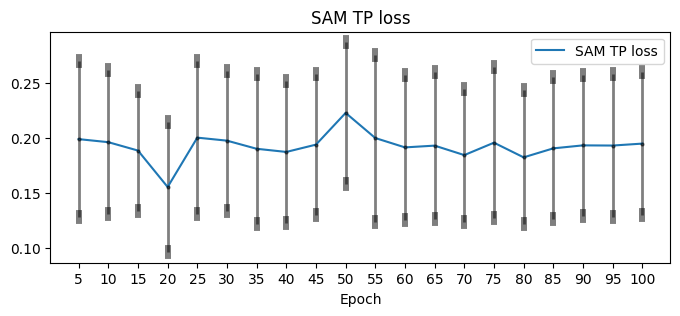

In [19]:
plot_loss_gen([sam_tp_loss_history], ["SAM TP loss"])

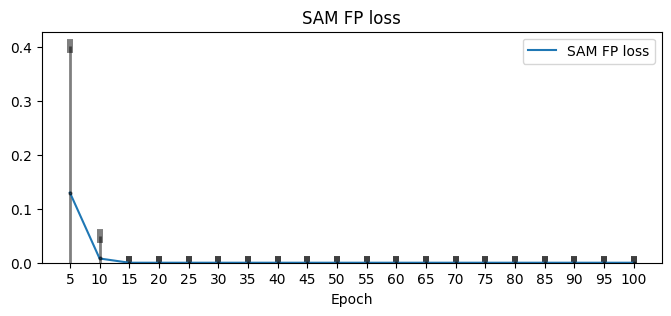

In [20]:
plot_loss_gen([sam_fp_loss_history], ["SAM FP loss"])

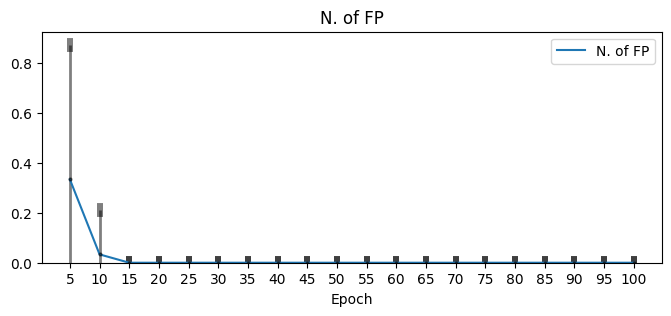

In [21]:
plot_loss_gen([n_false_positives_history], ["N. of FP"])

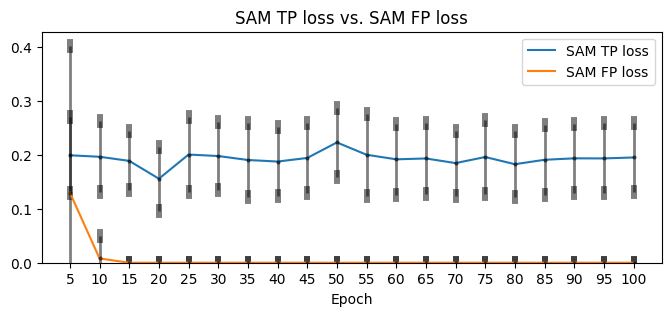

In [22]:
plot_loss_gen([sam_tp_loss_history, sam_fp_loss_history], ["SAM TP loss", "SAM FP loss"])